# FitzHugh–Nagumo benchmark of Ramsay et al. (2007): parametric forward problem in $(a, b)$ with time-marching PINNs (PyTorch)

Model of Ramsay, Hooker, Campbell & Cao (2007), JRSS-B 69(5), Section 3.1:

$$
\frac{dV}{dt} = c\left(V - \frac{V^3}{3} + R\right), \qquad
\frac{dR}{dt} = -\frac{1}{c}\,\big(V - a + b\,R\big), \qquad
V(0) = -1,\; R(0) = 1,
$$

with $c = 3$ fixed, on $t \in [0, 20]$.

Extension of `ramsay_fhn_forward_parametric_PINNs-torch.ipynb` to **two parameters**: the networks
take $(t, a, b)$ as input and are trained once for all $(a, b) \in [0.1, 0.5] \times [0.1, 0.5]$.
After training, the solution for any $(a, b)$ in that square is a single forward pass. This is still
the forward problem: no data and no parameter estimation. The networks are trained only on the ODE
residual, and RK45 is used purely for validation.

The solution oscillates for every $(a, b)$ in the square. The timing of the fronts depends on both
parameters (at larger $a$ and $b$ the third upstroke falls outside $[0, 20]$). For $b \gtrsim 0.8$
and larger $a$ the oscillation stops, which is why the range of $b$ stays well below that.

Framework, network structure and training loop are the same as in the $a$-only notebook: $[0, 20]$ is
split into windows of length 2, each window has its own MLP, and its initial condition is the end
state of the previous window, now as a function of $(a, b)$.

## Parameters (edit here)

In [1]:
# ---------------- ODE parameters (Ramsay et al. 2007, Sec. 3.1) ----------------
a_min, a_max = 0.1, 0.5   # range of the parameter a (network input)
b_min, b_max = 0.1, 0.5   # range of the parameter b (network input)
c = 3.0

# ---------------- Initial conditions ----------------
V0 = -1.0
R0 = 1.0

# ---------------- Time interval ----------------
t0      = 0.0
t_final = 20.0
n_eval  = 4000     # output grid in t for comparison

# ---------------- Time-marching PINN settings ----------------
window_length  = 2.0    # length of each time window
n_colloc       = 400    # collocation points in t per window (uniform grid)
n_a_train      = 11     # training values of a (uniform grid on [a_min, a_max])
n_b_train      = 11     # training values of b (uniform grid on [b_min, b_max])
hidden_layers  = 3
hidden_width   = 64
adam_epochs    = 500    # Adam warm-up per window
adam_lr        = 1.0e-3
lbfgs_max_iter = 3000   # L-BFGS refinement per window
seed           = 0
num_threads    = 16     # CPU threads for torch

# ---------------- Validation ----------------
n_a_test = 41           # test grid in a for the error map (includes values between training a)
n_b_test = 41           # test grid in b for the error map (includes values between training b)

## Imports and setup

In [2]:
import time
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # or "1" to use the second GPU

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import solve_ivp
from torch import nn

torch.manual_seed(seed)
np.random.seed(seed)
torch.set_num_threads(num_threads)

# float32 on GPU if available, otherwise CPU + float64 (same logic as the torch FHN notebook).
# In float32, L-BFGS typically stalls at residual losses ~1e-6.
if torch.cuda.is_available():
    device = torch.device("cuda")
    dtype = torch.float32
else:
    device = torch.device("cpu")
    dtype = torch.float64
# device = torch.device("cpu")
# dtype = torch.float64
print(f"torch {torch.__version__}, device {device}, dtype {dtype}")

torch 2.1.0, device cuda, dtype torch.float32


## Model

Inside window $[t_k, t_{k+1}]$, with $s = (t - t_k)/(t_{k+1} - t_k) \in [0, 1]$,
$\hat a = 2(a - a_{\min})/(a_{\max} - a_{\min}) - 1$ and $\hat b = 2(b - b_{\min})/(b_{\max} - b_{\min}) - 1$
(both in $[-1, 1]$),

$$
\big(V, R\big)(t, a, b) = \big(V_k, R_k\big)(a, b) + s\,\mathcal{N}_{\theta_k}(2s - 1,\ \hat a,\ \hat b),
$$

where $(V_k, R_k)(a, b)$ is the end state of window $k-1$ at the same $(a, b)$ (for $k = 0$, the initial
condition $(V_0, R_0)$). The initial condition and continuity between windows hold exactly for every $(a, b)$.

The loss is the mean squared ODE residual over the tensor grid of $t$ collocation points and training
values of $(a, b)$, with the same scaling as the fixed-$a$ notebook (both residuals $O(1)$):

$$
\mathcal{L} = \frac{1}{N}\sum_i \Big(\tfrac{1}{c}\dot V - V + \tfrac{V^3}{3} - R\Big)^2
+ \Big(c\,\dot R + V - a_i + b_i R\Big)^2 .
$$

In [3]:
class WindowPINN(nn.Module):
    # MLP on one time window, input (t, a, b), with a hard-coded ((a, b)-dependent) initial condition.

    def __init__(self, t_a, t_b, hidden_layers, hidden_width):
        super().__init__()
        self.t_a, self.t_b = t_a, t_b
        layers, width_in = [], 3
        for _ in range(hidden_layers):
            linear = nn.Linear(width_in, hidden_width)
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.Tanh()]
            width_in = hidden_width
        output = nn.Linear(width_in, 2)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.net = nn.Sequential(*layers)

    def forward(self, t, a, b, y_start):
        # t, a, b: (N, 1); y_start: (N, 2) state at t_a for each point's value of (a, b).
        s = (t - self.t_a) / (self.t_b - self.t_a)
        a_hat = 2.0 * (a - a_min) / (a_max - a_min) - 1.0
        b_hat = 2.0 * (b - b_min) / (b_max - b_min) - 1.0
        return y_start + s * self.net(torch.cat([2.0 * s - 1.0, a_hat, b_hat], dim=1))


def ode_residual(model, t, a, b, y_start):
    t = t.detach().requires_grad_(True)
    y = model(t, a, b, y_start)
    V, R = y[:, 0:1], y[:, 1:2]
    dV = torch.autograd.grad(V, t, torch.ones_like(V), create_graph=True)[0]
    dR = torch.autograd.grad(R, t, torch.ones_like(R), create_graph=True)[0]
    r_V = dV / c - (V - V**3 / 3.0 + R)
    r_R = c * dR + (V - a + b * R)
    return r_V, r_R


def residual_loss(model, t, a, b, y_start):
    r_V, r_R = ode_residual(model, t, a, b, y_start)
    return (r_V**2 + r_R**2).mean()


def window_start_states(models, a, b):
    # State (V, R) at the start of window len(models), for each (a, b) (tensors (N, 1)), by
    # marching through the already trained windows.
    y = torch.tensor([V0, R0], dtype=dtype, device=device).expand(a.shape[0], 2)
    with torch.no_grad():
        for model in models:
            t_end = torch.full_like(a, model.t_b)
            y = model(t_end, a, b, y)
    return y

## Train window by window (Adam warm-up, then L-BFGS)

Collocation points in window $k$ are the tensor grid of `n_colloc` values of $t$, `n_a_train`
values of $a$ and `n_b_train` values of $b$. The start state of each point comes from the already
trained windows at the same $(a, b)$ and is fixed (no gradient) while window $k$ is trained.

In [4]:
a_train = torch.linspace(a_min, a_max, n_a_train, dtype=dtype, device=device)
b_train = torch.linspace(b_min, b_max, n_b_train, dtype=dtype, device=device)


def train_window(t_a, t_b, models):
    model = WindowPINN(t_a, t_b, hidden_layers, hidden_width).to(device, dtype)
    t_grid = torch.linspace(t_a, t_b, n_colloc, dtype=dtype, device=device)
    T, A, B = torch.meshgrid(t_grid, a_train, b_train, indexing="ij")
    t_col, a_col, b_col = T.reshape(-1, 1), A.reshape(-1, 1), B.reshape(-1, 1)
    y_start = window_start_states(models, a_col, b_col)
    history = []

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    for _ in range(adam_epochs):
        adam.zero_grad()
        loss = residual_loss(model, t_col, a_col, b_col, y_start)
        loss.backward()
        adam.step()
        history.append(loss.item())

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=lbfgs_max_iter,
        history_size=100,
        tolerance_grad=1e-12,
        tolerance_change=1e-16,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()
        loss = residual_loss(model, t_col, a_col, b_col, y_start)
        loss.backward()
        history.append(loss.item())
        return loss

    lbfgs.step(closure)
    return model, history


edges = np.arange(t0, t_final + 1e-9, window_length)
if edges[-1] < t_final:
    edges = np.append(edges, t_final)

models, histories = [], []
start = time.time()
for t_a, t_b in zip(edges[:-1], edges[1:]):
    model, history = train_window(float(t_a), float(t_b), models)
    models.append(model)
    histories.append(history)
    print(f"window [{t_a:5.1f}, {t_b:5.1f}]  final loss {history[-1]:.2e}  "
          f"({len(history)} evals, {time.time() - start:.0f}s)")

window [  0.0,   2.0]  final loss 5.97e-07  (1357 evals, 12s)
window [  2.0,   4.0]  final loss 6.28e-07  (2170 evals, 34s)
window [  4.0,   6.0]  final loss 1.13e-06  (3647 evals, 74s)
window [  6.0,   8.0]  final loss 2.14e-06  (3622 evals, 114s)
window [  8.0,  10.0]  final loss 2.08e-06  (3686 evals, 154s)
window [ 10.0,  12.0]  final loss 3.23e-06  (3659 evals, 194s)
window [ 12.0,  14.0]  final loss 1.84e-06  (3291 evals, 228s)
window [ 14.0,  16.0]  final loss 2.83e-06  (3620 evals, 268s)
window [ 16.0,  18.0]  final loss 2.47e-06  (3623 evals, 308s)
window [ 18.0,  20.0]  final loss 4.85e-06  (3664 evals, 348s)


## Evaluate the PINN and the RK45 reference on a grid of $(a, b)$

`pinn_predict(t, ab)` returns $V$ and $R$ at times `t` for each parameter pair in `ab` (shape
`(n_pairs, 2)`). The error map uses an `n_a_test` × `n_b_test` grid of $(a, b)$, most of which lie
between the training values.

In [5]:
def pinn_predict(t, ab):
    # Evaluate the piecewise parametric PINN; returns V, R with shape (len(ab), len(t)).
    t = np.asarray(t, dtype=np.float64)
    ab = np.asarray(ab, dtype=np.float64)
    n_p = ab.shape[0]
    a_col = torch.tensor(ab[:, 0:1], dtype=dtype, device=device)
    b_col = torch.tensor(ab[:, 1:2], dtype=dtype, device=device)
    idx = np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(models) - 1)
    out = np.empty((n_p, t.size, 2))
    y_start = torch.tensor([V0, R0], dtype=dtype, device=device).expand(n_p, 2)
    with torch.no_grad():
        for k, model in enumerate(models):
            mask = idx == k
            if mask.any():
                tk = torch.tensor(t[mask], dtype=dtype, device=device)
                n_t = tk.numel()
                T = tk[:, None].expand(n_t, n_p).reshape(-1, 1)                 # (n_t * n_p, 1)
                A = a_col[None].expand(n_t, n_p, 1).reshape(-1, 1)
                B = b_col[None].expand(n_t, n_p, 1).reshape(-1, 1)
                Y0 = y_start[None].expand(n_t, n_p, 2).reshape(-1, 2)
                y = model(T, A, B, Y0)
                out[:, mask] = y.reshape(n_t, n_p, 2).transpose(0, 1).cpu().numpy()
            y_start = model(torch.full_like(a_col, model.t_b), a_col, b_col, y_start)
    return out[..., 0], out[..., 1]


def fitzhugh_nagumo_ramsay(t, y, a, b, c):
    V, R = y
    dV = c * (V - V**3 / 3.0 + R)
    dR = -(V - a + b * R) / c
    return [dV, dR]


t = np.linspace(t0, t_final, n_eval)
a_test = np.linspace(a_min, a_max, n_a_test)
b_test = np.linspace(b_min, b_max, n_b_test)
AA, BB = np.meshgrid(a_test, b_test, indexing="ij")           # (n_a_test, n_b_test)
ab_test = np.column_stack([AA.ravel(), BB.ravel()])
V, R = pinn_predict(t, ab_test)

# Tight tolerances so the reference error is negligible next to the PINN error.
V_ref, R_ref = np.empty_like(V), np.empty_like(R)
start_ref = time.time()
for i, (a, b) in enumerate(ab_test):
    sol = solve_ivp(fitzhugh_nagumo_ramsay, (t0, t_final), [V0, R0], method="RK45", t_eval=t,
                    args=(a, b, c), rtol=1e-10, atol=1e-12)
    V_ref[i], R_ref[i] = sol.y
print(f"RK45 reference for {len(ab_test)} parameter pairs: {time.time() - start_ref:.0f}s")

rel_l2 = np.sqrt(np.sum((V - V_ref)**2 + (R - R_ref)**2, axis=1)
                 / np.sum(V_ref**2 + R_ref**2, axis=1)).reshape(AA.shape)
i_max = np.unravel_index(rel_l2.argmax(), rel_l2.shape)
print(f"relative L2 error (V, R) over (a, b) in [{a_min}, {a_max}] x [{b_min}, {b_max}]: "
      f"mean {rel_l2.mean():.3e}, max {rel_l2.max():.3e} "
      f"(at a = {a_test[i_max[0]]:.3f}, b = {b_test[i_max[1]]:.3f})")
print(f"max |V - V_ref| = {np.abs(V - V_ref).max():.3e},  max |R - R_ref| = {np.abs(R - R_ref).max():.3e}")

RK45 reference for 1681 parameter pairs: 154s
relative L2 error (V, R) over (a, b) in [0.1, 0.5] x [0.1, 0.5]: mean 3.544e-03, max 5.600e-02 (at a = 0.500, b = 0.500)
max |V - V_ref| = 3.513e-01,  max |R - R_ref| = 7.877e-02


## Relative error over $(a, b)$

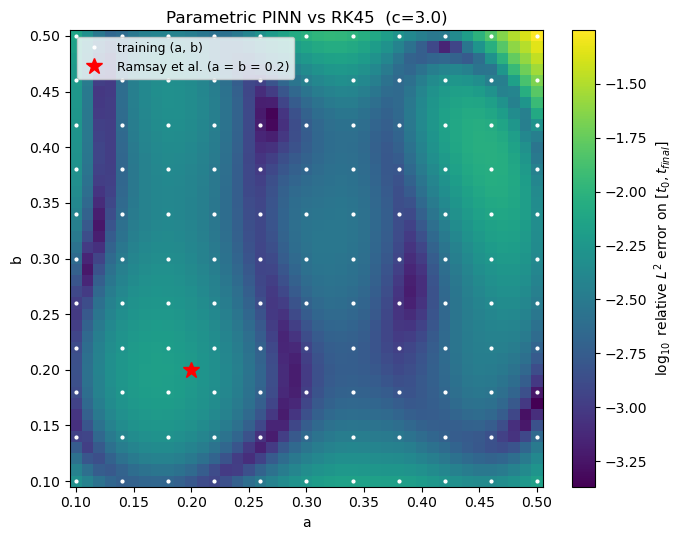

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
mesh = ax.pcolormesh(a_test, b_test, np.log10(rel_l2).T, shading="nearest", cmap="viridis")
# mesh = ax.pcolormesh(a_test, b_test, rel_l2.T, shading="nearest", cmap="viridis")
fig.colorbar(mesh, ax=ax, label=r"$\log_{10}$ relative $L^2$ error on $[t_0, t_{final}]$")
At, Bt = np.meshgrid(a_train.cpu().numpy(), b_train.cpu().numpy(), indexing="ij")
ax.plot(At.ravel(), Bt.ravel(), "w.", ms=4, label="training (a, b)")
ax.plot(0.2, 0.2, "r*", ms=12, label="Ramsay et al. (a = b = 0.2)")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title(f"Parametric PINN vs RK45  (c={c})")
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.show()

In [24]:
np.log10(3.e-2)

-1.5228787452803376

## Training history per window

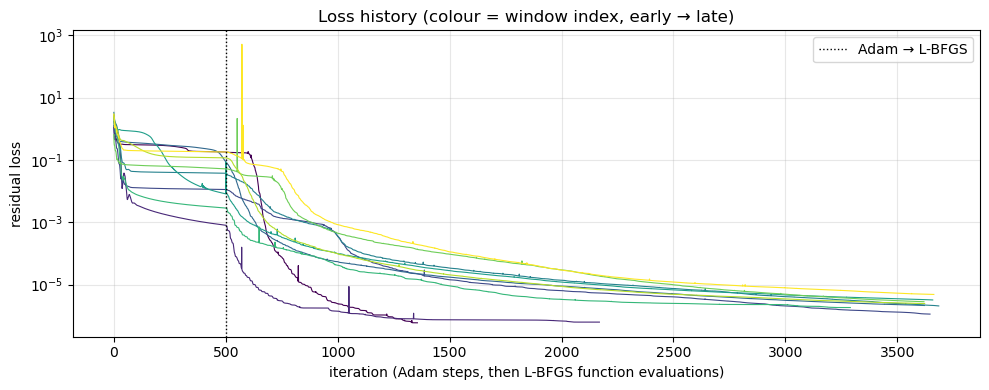

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.get_cmap("viridis")
for k, history in enumerate(histories):
    ax.semilogy(history, color=cmap(k / max(len(histories) - 1, 1)), lw=0.8)
ax.axvline(adam_epochs, color="k", ls=":", lw=1, label="Adam → L-BFGS")
ax.set_xlabel("iteration (Adam steps, then L-BFGS function evaluations)")
ax.set_ylabel("residual loss")
ax.set_title("Loss history (colour = window index, early → late)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()